# Baseline + Harness de Avaliação

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** medir o "ANTES" do modelo (a base de comparação de todas as questões).
- **Método (3 métricas):** perplexidade/entropia/acc-token (Q1); similaridade semântica das respostas; acurácia MCQ por log-prob (cloze).
- **Modelo / Dados:** Qwen3 (1.7B→4B) · `gutoportelaa/dom-pi-corpus-2025` · benchmark próprio.

## Passo a passo
1. Carrega o Qwen3-4B em 4-bit.
2. Mede as métricas de linguagem no texto do domínio: entropia cruzada, perplexidade e acurácia de token.
3. Avalia as perguntas abertas por similaridade semântica e por acerto factual.
4. Avalia a múltipla escolha (MCQ) por log-prob/cloze.
5. Salva o "antes" em baseline.json, que é a referência de comparação para todas as questões.

### Setup — montar o Google Drive e entrar na pasta (persiste os resultados)

In [6]:
# Necessário p/ os results_qN.json caírem no Drive (não no /content efêmero). Fora do Colab, pule.
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ufpi/topics-in-ai/final-project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ufpi/topics-in-ai/final-project


In [5]:
from pathlib import Path
import os

diretorio = Path("/content/drive/MyDrive/ufpi/topics-in-ai/final-project")
if not os.path.exists(diretorio):
  os.makedirs(diretorio)
  %cd "/content/drive/MyDrive/ufpi/topics-in-ai/final-project"

### Instalação

In [7]:
!pip -q install -U transformers accelerate sentence-transformers datasets bitsandbytes
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.3 MB/s eta 0:00:00


### Modelo (seletor de modo)

In [8]:
import torch, math, json
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODE = "oficial"        # "smoke" (1.7B) ou "oficial" (4B) — mesma quantização 4-bit dos demais notebooks
MODEL_ID = {"smoke": "Qwen/Qwen3-1.7B", "oficial": "Qwen/Qwen3-4B"}[MODE]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"MODE={MODE} | modelo={MODEL_ID}")

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map="auto").eval()
print("modelo:", MODEL_ID)

MODE=oficial | modelo=Qwen/Qwen3-4B


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

modelo: Qwen/Qwen3-4B


### Geração (chat) — thinking DESLIGADO p/ avaliação limpa

In [9]:
def gerar(pergunta, contexto=None, max_new=96):   # respostas do benchmark são curtas; 96 basta e acelera
    sys = "Responda de forma objetiva e em português."
    user = pergunta if not contexto else f"Contexto:\n{contexto}\n\nPergunta: {pergunta}"
    msgs = [{"role": "system", "content": sys}, {"role": "user", "content": user}]
    ids = tok.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True,
                                  enable_thinking=False, return_tensors="pt", return_dict=True).to(model.device)
    out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                         pad_token_id=tok.pad_token_id)
    return tok.decode(out[0, ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()

### Métricas de LM (Q1): perplexidade, entropia cruzada, acc. de token

In [10]:
@torch.no_grad()
def metricas_lm(texto, janela=1024):
    ids = tok(texto, return_tensors="pt").input_ids.to(model.device)
    nll, n_tok, acertos = 0.0, 0, 0
    for i in range(0, ids.size(1) - 1, janela):
        chunk = ids[:, i:i + janela + 1]
        if chunk.size(1) < 2:
            break
        logits = model(chunk[:, :-1]).logits
        alvo = chunk[:, 1:]
        nll += torch.nn.functional.cross_entropy(
            logits.reshape(-1, logits.size(-1)), alvo.reshape(-1), reduction="sum").item()
        n_tok += alvo.numel()
        acertos += (logits.argmax(-1) == alvo).sum().item()
    ce = nll / n_tok
    return {"cross_entropy": round(ce, 4), "perplexidade": round(math.exp(ce), 2),
            "acc_token": round(acertos / n_tok, 4)}

### Benchmark DOM-PI (30 perguntas verificáveis no corpus) — ver benchmark_dompi.json

In [11]:
benchmark = [
    {"q": "Qual o valor do crédito suplementar aberto pela Portaria nº 790, de 12/12/2025, de Teresina?", "ref": "R$ 1.103.110,00"},
    {"q": "De qual município é a Portaria nº 790/2025 que abre crédito suplementar de R$ 1.103.110,00?", "ref": "Teresina"},
    {"q": "Qual o valor do crédito suplementar da Portaria nº 143, de 19 de maio de 2025 (Teresina)?", "ref": "R$ 300.000,00"},
    {"q": "Qual o valor do crédito suplementar aberto pela Portaria nº 242, de 03 de julho de 2025?", "ref": "R$ 30.000,00"},
    {"q": "Qual autoridade assina as portarias de crédito suplementar do Município de Teresina?", "ref": "O Secretário Municipal de Planejamento e Coordenação"},
    {"q": "Qual o valor mensal do Contrato de Locação nº 004/2025 da Prefeitura de Várzea Branca?", "ref": "R$ 500,00 por mês"},
    {"q": "Qual a vigência do Contrato de Locação nº 004/2025 de Várzea Branca?", "ref": "12 meses, podendo ser prorrogado"},
    {"q": "Qual empresa venceu a Concorrência Eletrônica nº 001/2025 do município de Cocal?", "ref": "F Santos Construtora e Serviços LTDA"},
    {"q": "Qual o valor do contrato da Concorrência Eletrônica nº 001/2025 de Cocal?", "ref": "R$ 3.617.082,24"},
    {"q": "Qual o objeto da Concorrência Eletrônica nº 001/2025 do município de Cocal?", "ref": "Pavimentação de vias públicas em paralelepípedo"},
    {"q": "Qual empresa foi adjudicada para a recuperação de estradas vicinais em Barras?", "ref": "Liderança Construtora LTDA"},
    {"q": "Por qual valor foi adjudicada a recuperação de estradas vicinais em Barras?", "ref": "R$ 827.500,00"},
    {"q": "O que regulamenta o decreto do município de São Raimundo Nonato de 24/10/2025?", "ref": "Institui/regulamenta o IPTU Premiado"},
    {"q": "Qual cargo é objeto de exoneração na Portaria nº 104/2025 de Pajeú do Piauí?", "ref": "Chefe do Setor de Transporte e Máquinas"},
    {"q": "Que fundo municipal é criado pela norma do município de Jaicós (art. 16)?", "ref": "Fundo Municipal de Direitos do Idoso"},
    {"q": "Qual o objeto do contrato por inexigibilidade nº 005/2025 da Câmara Municipal de Gilbués?", "ref": "Consultoria e assessoria em gestão de folha de pagamento e assessoria fiscal e previdenciária"},
    {"q": "Quem foi nomeada Assessor de Gabinete pela Portaria nº 142/2025 (Tamboril do Piauí)?", "ref": "Esther de Aguiar Luz"},
    {"q": "Para qual cargo comissionado foi nomeada Esther de Aguiar Luz na Portaria nº 142/2025?", "ref": "Assessor de Gabinete (DAS CC-4)"},
    {"q": "Qual o tipo da licitação (Pregão Eletrônico nº 048/2025) de Redenção do Gurguéia?", "ref": "Menor preço por lote"},
    {"q": "Qual a modalidade de licitação da Ata de Registro de Preços nº 0021/2025 de Lagoa de São Francisco?", "ref": "Pregão"},
    {"q": "Quais profissionais o Edital de Chamada Pública nº 001/2025 (Ribeiro Gonçalves) busca contratar?", "ref": "Operadores de pá escavadeira, retroescavadeira e motoniveladora"},
    {"q": "Qual o cargo da Chamada Pública Simplificada nº 002/2025 de Ribeira do Piauí?", "ref": "Cuidador Escolar"},
    {"q": "Qual a carga horária do cargo da Chamada Pública nº 002/2025 de Ribeira do Piauí?", "ref": "40 horas"},
    {"q": "Qual o objeto da Inexigibilidade de Licitação nº 019/2025 de Parnaguá?", "ref": "Assessoria técnica em saúde para a gestão municipal do SUS"},
    {"q": "Por que foi emitido o Termo de Retificação ao Aditivo nº 011/2025 de Sebastião Leal?", "ref": "Erro de digitação na cláusula de vigência"},
    {"q": "Qual decreto é corrigido pela errata publicada por São Lourenço do Piauí?", "ref": "Decreto nº 028/2025"},
    {"q": "A que exercício se refere o Orçamento-Programa da Câmara Municipal de Boqueirão do Piauí?", "ref": "Exercício de 2026"},
    {"q": "Qual a lei federal de licitações e contratos citada como fundamento nos atos do DOM-PI?", "ref": "Lei nº 14.133/2021"},
    {"q": "Classifique o tipo de ato: 'Abre Crédito Suplementar no Orçamento-Programa vigente, no valor de R$ 30.000,00'.", "ref": "Portaria"},
    {"q": "O Diário Oficial dos Municípios (DOM) usado neste corpus é de qual estado?", "ref": "Piauí"},
]

### Avaliação de QA — similaridade semântica + ACERTO FACTUAL (multilingual-e5-small)

In [12]:
import re, unicodedata
from sentence_transformers import SentenceTransformer, util
emb = SentenceTransformer("intfloat/multilingual-e5-small", device=DEVICE)

def _norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = re.sub(r"\([^)]*\)", " ", s)               # ignora parênteses (ex.: "(um milhão...)")
    return re.sub(r"[^a-z0-9]+", " ", s).strip()
def acerto_factual(resp, ref):
    nr = _norm(ref)
    return int(bool(nr) and nr in _norm(resp))     # a resposta de referência aparece na resposta?

# Similaridade SATURA (uma resposta errada no mesmo tema pontua alto) — por isso medimos também o
# ACERTO FACTUAL: a referência aparece (normalizada) na resposta? Ex.: "Teresina" vs "São João del
# Rei" dá sim ~0,80 mas factual = 0. A acurácia MCQ (Cell 8) é a métrica de fato principal.
def avaliar_qa(bench, contexto_fn=None):
    rows, sims, acertos = [], [], []
    for it in bench:
        ctx = contexto_fn(it["q"]) if contexto_fn else None
        resp = gerar(it["q"], ctx)
        s = util.cos_sim(emb.encode(resp, normalize_embeddings=True),
                         emb.encode(it["ref"], normalize_embeddings=True)).item()
        a = acerto_factual(resp, it["ref"])
        sims.append(s); acertos.append(a)
        rows.append({"q": it["q"], "resp": resp, "sim": round(s, 3), "factual": a})
    return {"sim": round(sum(sims) / len(sims), 3), "factual": round(sum(acertos) / len(acertos), 3)}, rows

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

### Rodar baseline e salvar

In [13]:
# Texto real do diariosPrefeituras (DOM-PI) direto do HF — sem upload.
from datasets import load_dataset
corpus = load_dataset("gutoportelaa/dom-pi-corpus-2025", "curated", split="train")
# held-out p/ perplexidade: amostra de documentos curados
texto_holdout = "\n\n".join(corpus.shuffle(seed=42).select(range(20))["texto"])[:20000]
lm = metricas_lm(texto_holdout)
qa, detalhe = avaliar_qa(benchmark)
print("LM (baseline):", lm)
print(f"QA (baseline): similaridade média = {qa['sim']} | acerto factual = {qa['factual']}")
json.dump({"modelo": MODEL_ID, "lm": lm, "qa_sim": qa["sim"], "qa_factual": qa["factual"], "detalhe": detalhe},
          open("baseline.json", "w"), ensure_ascii=False, indent=2)
print("-> baseline.json salvo (é o 'antes' de tudo)")

README.md:   0%|          | 0.00/6.07k [00:00<?, ?B/s]

curated/curated-00000-of-00002.parquet:   0%|          | 0.00/118M [00:00<?, ?B/s]

curated/curated-00001-of-00002.parquet:   0%|          | 0.00/50.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70826 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


LM (baseline): {'cross_entropy': 2.3353, 'perplexidade': 10.33, 'acc_token': 0.5531}
QA (baseline): similaridade média = 0.833 | acerto factual = 0.0
-> baseline.json salvo (é o 'antes' de tudo)


### Múltipla escolha (T1) — Acurácia por LOG-PROB (cloze). Ver benchmark_dompi_mcq.json

In [14]:
mcq = [
    {"q": "Valor do crédito suplementar da Portaria nº 790/2025 (Teresina)?",
     "options": ["R$ 1.103.110,00", "R$ 300.000,00", "R$ 30.000,00", "R$ 827.500,00"], "answer": 0},
    {"q": "Valor do crédito suplementar da Portaria nº 143/2025 (Teresina)?",
     "options": ["R$ 30.000,00", "R$ 300.000,00", "R$ 1.103.110,00", "R$ 3.617.082,24"], "answer": 1},
    {"q": "Empresa vencedora da Concorrência Eletrônica nº 001/2025 de Cocal?",
     "options": ["Liderança Construtora LTDA", "F Santos Construtora e Serviços LTDA", "Souza Edilson Sérvulo de Souza", "Caio Henrique Braga Paes"], "answer": 1},
    {"q": "Valor do contrato da Concorrência Eletrônica nº 001/2025 de Cocal?",
     "options": ["R$ 827.500,00", "R$ 1.103.110,00", "R$ 3.617.082,24", "R$ 835.335,20"], "answer": 2},
    {"q": "Empresa adjudicada para recuperação de estradas vicinais em Barras?",
     "options": ["Liderança Construtora LTDA", "F Santos Construtora e Serviços LTDA", "Famae Peças", "Liderança Pavimentação ME"], "answer": 0},
    {"q": "Cargo exonerado na Portaria nº 104/2025 de Pajeú do Piauí?",
     "options": ["Assessor de Gabinete", "Cuidador Escolar", "Chefe do Setor de Transporte e Máquinas", "Diretor de Departamento"], "answer": 2},
    {"q": "Fundo municipal criado pela norma de Jaicós (art. 16)?",
     "options": ["Fundo Municipal de Saúde", "Fundo Municipal de Direitos do Idoso", "Fundo Municipal de Educação", "Fundo Municipal de Assistência Social"], "answer": 1},
    {"q": "O decreto de São Raimundo Nonato (24/10/2025) trata de quê?",
     "options": ["IPTU Premiado", "Crédito suplementar", "Chamada pública de cuidadores", "Locação de imóvel"], "answer": 0},
    {"q": "Carga horária do cargo da Chamada Pública nº 002/2025 de Ribeira do Piauí?",
     "options": ["20 horas", "30 horas", "40 horas", "44 horas"], "answer": 2},
    {"q": "Critério da licitação Pregão Eletrônico nº 048/2025 de Redenção do Gurguéia?",
     "options": ["Maior lance", "Menor preço por lote", "Técnica e preço", "Melhor técnica"], "answer": 1},
    {"q": "Objeto da Inexigibilidade nº 019/2025 de Parnaguá?",
     "options": ["Pavimentação de vias", "Assessoria técnica em saúde (SUS)", "Recuperação de estradas", "Fornecimento de merenda"], "answer": 1},
    {"q": "Lei federal de licitações citada como fundamento nos atos do DOM-PI?",
     "options": ["Lei nº 8.666/1993", "Lei nº 14.133/2021", "Lei nº 4.320/1964", "Lei nº 10.520/2002"], "answer": 1},
    {"q": "Tipo de ato: 'Abre Crédito Suplementar no valor de R$ 30.000,00'.",
     "options": ["Decreto", "Portaria", "Edital", "Contrato"], "answer": 1},
]

@torch.no_grad()
def score_mcq(pergunta, opcoes):
    # Scoring CLOZE: log-prob média dos tokens de cada opção -> escolhe a maior (menor perplexidade)
    msgs = [{"role": "user", "content": f"{pergunta}\nResponda apenas com a alternativa correta."}]
    base = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    base_ids = tok(base, return_tensors="pt").input_ids.to(model.device)
    scores = []
    for op in opcoes:
        op_ids = tok(" " + op, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
        full = torch.cat([base_ids, op_ids], dim=1)
        labels = full.clone(); labels[:, :base_ids.shape[1]] = -100   # mede só a opção
        loss = model(full, labels=labels).loss.item()               # CE média da opção
        scores.append(-loss)                                        # maior = mais provável
    return int(max(range(len(opcoes)), key=lambda i: scores[i]))

def avaliar_mcq(itens):
    acertos = 0
    for it in itens:
        if score_mcq(it["q"], it["options"]) == it["answer"]:
            acertos += 1
    return acertos / len(itens)

acc = avaliar_mcq(mcq)
print(f"Acurácia MCQ (baseline): {acc:.3f}  | aleatório = 0.25")

Acurácia MCQ (baseline): 0.154  | aleatório = 0.25


## Conclusão
Estes são os números de **referência (antes)**: perplexidade, similaridade e acurácia MCQ.
Toda comparação (pré-treino, SFT, RAG, destilação) é medida contra esta baseline.

### Gráfico do resultado — a saturação da similaridade

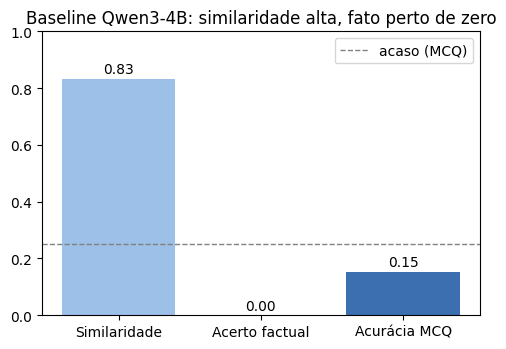

In [15]:
import matplotlib.pyplot as plt
labs = ["Similaridade", "Acerto factual", "Acurácia MCQ"]
vals = [qa["sim"], qa["factual"], acc]
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.bar(labs, vals, color=["#9cc0e8", "#d98a2b", "#3b6fb0"])
ax.axhline(0.25, ls="--", c="gray", lw=1, label="acaso (MCQ)")
ax.set_ylim(0, 1); ax.set_title("Baseline Qwen3-4B: similaridade alta, fato perto de zero")
for i, v in enumerate(vals): ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.legend(); plt.tight_layout(); plt.show()